# 14 - Mini‑EDA guiado con Matplotlib y Plotly

Objetivos:
- Revisión rápida de calidad de datos (nulos, duplicados, estadísticos).
- Visualizar relaciones clave con **Matplotlib** y **Plotly**.
- Generar un par de **insights** apoyados en gráficos.


## 1. Cargar datos (o generar sintético)

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path

csv_default = Path("/mnt/data/clientes_sintetico.csv")
if csv_default.exists():
    df = pd.read_csv(csv_default)
else:
    rng = np.random.default_rng(2)
    n = 400
    df = pd.DataFrame({
        "id": range(1, n+1),
        "edad": rng.integers(18, 70, size=n),
        "ingresos": rng.normal(26000, 9000, size=n).round(2),
        "ciudad": rng.choice(["Cádiz","Sevilla","Málaga","Córdoba"], size=n),
        "compra": rng.choice([0,1], size=n, p=[0.4, 0.6]),
        "satisfaccion": rng.integers(1, 6, size=n),
    })
df.head()

,id,edad,ingresos,ciudad,compra,satisfaccion
0,1,61,27843.82,Málaga,1,5
1,2,31,15913.90,Cádiz,0,3
2,3,23,39012.24,Cádiz,0,3
3,4,33,9093.07,Córdoba,1,1
4,5,39,30528.84,Córdoba,0,1


## 2. Chequeos básicos

In [3]:
df.shape, df.isna().sum(), df.duplicated().sum(), df.describe()

((400, 6),
 id              0
 edad            0
 ingresos        0
 ciudad          0
 compra          0
 satisfaccion    0
 dtype: int64,
 np.int64(0),
                id        edad      ingresos      compra  satisfaccion
 count  400.000000  400.000000    400.000000  400.000000    400.000000
 mean   200.500000   43.920000  25258.542000    0.642500      3.022500
 std    115.614301   14.954688   9112.881026    0.479864      1.418458
 min      1.000000   18.000000   1829.640000    0.000000      1.000000
 25%    100.750000   31.000000  19083.280000    0.000000      2.000000
 50%    200.500000   44.000000  24865.220000    1.000000      3.000000
 75%    300.250000   57.000000  31291.515000    1.000000      4.000000
 max    400.000000   69.000000  53507.080000    1.000000      5.000000)

## 3. Visualizaciones clave

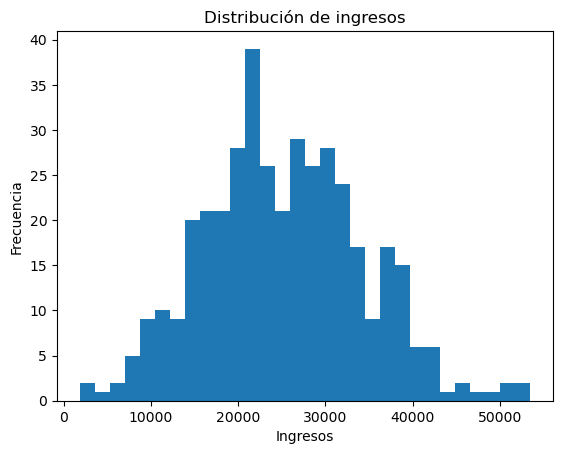

In [4]:
# Matplotlib: histograma de ingresos
plt.figure()
plt.hist(df["ingresos"].dropna(), bins=30)
plt.title("Distribución de ingresos")
plt.xlabel("Ingresos"); plt.ylabel("Frecuencia")
plt.show()

In [5]:
# Plotly: dispersión edad vs ingresos por ciudad
fig = px.scatter(df, x="edad", y="ingresos", color="ciudad", hover_data=["satisfaccion"])
fig.update_layout(title="Edad vs Ingresos por ciudad (interactivo)")
fig.show()

## 4. Agrupaciones e insights

In [7]:
agg = (df.groupby("ciudad")
         .agg(media_ingresos=("ingresos","mean"),
              tasa_compra=("compra","mean"),
              n=("id","count"))
         .reset_index()
      )
agg.sort_values("media_ingresos", ascending=False)

,ciudad,media_ingresos,tasa_compra,n
1,Córdoba,26400.247471,0.643678,87
0,Cádiz,26335.185980,0.607843,102
3,Sevilla,24636.744574,0.691489,94
2,Málaga,23970.532564,0.632479,117


## 📝 Ejercicios

1) Detecta **outliers** en `ingresos` (IQR) y muestra cuántos hay.  
2) Haz un **boxplot** de `satisfaccion` por `ciudad` (puede ser Matplotlib o Plotly).  
3) Escribe **dos conclusiones** sobre el comportamiento por ciudad en función de `media_ingresos` y `tasa_compra`.
